In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
%matplotlib inline

**Contexto**

El conjunto de datos se compone de información recopilada de camiones pesados ​​Scania durante su uso cotidiano. El sistema objeto de estudio es el sistema de aire a presión (APS), el cual genera aire comprimido utilizado para diversas funciones del camión, tales como el frenado y el cambio de marchas. La clase positiva del conjunto de datos comprende los fallos de un componente específico del sistema APS, mientras que la clase negativa incluye camiones con fallos en componentes ajenos a dicho sistema.

El conjunto de entrenamiento contiene un total de 60.000 ejemplos, de los cuales 59.000 pertenecen a la clase negativa y 1.000 a la clase positiva. El conjunto de prueba contiene 16.000 ejemplos. Hay 171 atributos por registro.

Los nombres de los atributos de los datos han sido anonimizados por razones de propiedad. Estos consisten tanto en contadores numéricos individuales como en histogramas formados por intervalos (o *bins*) con diferentes condiciones. Por lo general, los histogramas presentan condiciones de rango abierto en ambos extremos. Por ejemplo, si se mide la temperatura ambiente "T", el histograma podría definirse con 4 intervalos donde:

Los atributos son los siguientes: la clase, seguida de datos operativos anonimizados. Los datos operativos cuentan con un identificador y un identificador de intervalo, con el formato "Identificador_Intervalo". En total hay 171 atributos, de los cuales 7 son variables de histograma. Los valores faltantes se indican mediante "na".

**Inspiración**

El costo total de un modelo de predicción es la suma del Costo_1 multiplicado por el número de instancias con fallas de tipo 1 y el Costo_2 multiplicado por el número de instancias con fallas de tipo 2, lo que resulta en un Costo_Total. En este caso, el Costo_1 se refiere al costo de una revisión innecesaria realizada por un mecánico en un taller, mientras que el Costo_2 se refiere al costo de no detectar un camión defectuoso, lo que podría causar una avería. Costo_1 = 10 y Costo_2 = 500, y Costo_Total = Costo_1 * Número_de_Instancias + Costo_2 * Número_de_Instancias.

In [ ]:
train = pd.read_csv('aps_failure_training_set.csv', skiprows=20, na_values='na')
test = pd.read_csv('aps_failure_test_set.csv', skiprows=20, na_values='na')

In [36]:
train.shape

(60000, 171)

In [37]:
test.shape

(16000, 171)

In [38]:
from sklearn.impute import SimpleImputer

# cd_000 es constante (unico valor no nulo) -> no aporta info, se descarta
train = train.drop(columns=['cd_000'])
test  = test.drop(columns=['cd_000'])

feature_cols = train.columns.drop('class')
imputer = SimpleImputer(strategy='median')
train[feature_cols] = imputer.fit_transform(train[feature_cols])
test[feature_cols] = imputer.transform(test[feature_cols])


In [39]:
train.shape

(60000, 170)

In [40]:
threshold = 0.9

# corremos la correlacion sobre las variables continuas originales, sin 'class'
corr_matrix = train[feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# de cada par con |r| > threshold, nos quedamos con una y descartamos la otra
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print(f'Columnas eliminadas por alta correlacion (> {threshold}): {len(to_drop)} de {len(feature_cols)}')
print(to_drop)

train = train.drop(columns=to_drop)
test  = test.drop(columns=to_drop)

print('shape train:', train.shape, 'shape test:', test.shape)


Columnas eliminadas por alta correlacion (> 0.9): 43 de 169
['am_0', 'an_000', 'ao_000', 'aq_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'bb_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bt_000', 'bu_000', 'bv_000', 'by_000', 'cc_000', 'cf_000', 'ci_000', 'cn_004', 'cn_005', 'co_000', 'cq_000', 'cs_005', 'dc_000', 'dn_000', 'dp_000', 'dt_000', 'ed_000', 'ee_000', 'ee_001', 'ee_002', 'ee_003', 'ee_004']
shape train: (60000, 127) shape test: (16000, 127)


In [41]:
train.shape

(60000, 127)

In [42]:
test.shape

(16000, 127)

In [43]:
X_train_full = train.drop(columns='class')
y_train_full = train['class'].map({'neg': 0, 'pos': 1})

X_test = test.drop(columns='class')
y_test = test['class'].map({'neg': 0, 'pos': 1})


In [44]:
X_train_full.shape, y_train_full.shape, X_test.shape, y_test.shape

((60000, 126), (60000,), (16000, 126), (16000,))

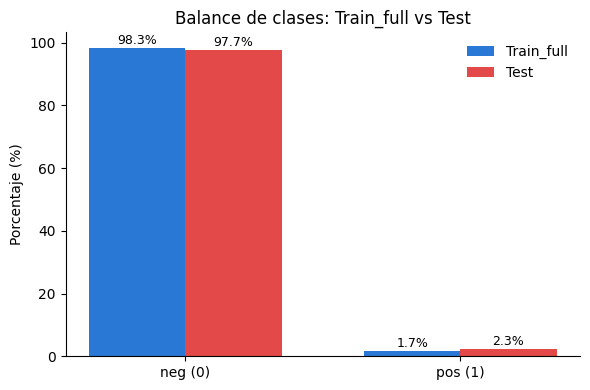

In [45]:
counts_train = y_train_full.value_counts(normalize=True).sort_index() * 100
counts_test  = y_test.value_counts(normalize=True).sort_index() * 100

labels = ['neg (0)', 'pos (1)']
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars_train = ax.bar([i - width/2 for i in x], counts_train.values, width, label='Train_full', color='#2a78d6')
bars_test  = ax.bar([i + width/2 for i in x], counts_test.values, width, label='Test', color='#e34948')

ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Balance de clases: Train_full vs Test')
ax.legend(frameon=False)

for bars in [bars_train, bars_test]:
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:.1f}%', xy=(b.get_x() + b.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Vamos a dividir el X_train_full y el y_train_full en un set de train y otro de validacion

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,  # importante por el desbalance
    random_state=42
)

In [74]:
X_train_full.shape, y_train_full.shape, X_train.shape, y_train.shape, X_val.shape, y_val.shape

((60000, 126), (60000,), (48000, 126), (48000,), (12000, 126), (12000,))

### Vamos a verificar cuales son las variables con mayor correlacion respecto del Target

aa_000    0.536978
ah_000    0.512991
bx_000    0.505529
ap_000    0.503651
ee_005    0.485831
ck_000    0.464198
ag_005    0.448212
cs_004    0.437519
ag_003    0.433050
az_005    0.432062
ba_000    0.430719
ee_006    0.415300
ay_008    0.409810
cn_003    0.406036
cs_003    0.391673
cn_001    0.390680
cs_002    0.372410
ag_004    0.371622
ag_006    0.368423
cn_002    0.367792
dtype: float64


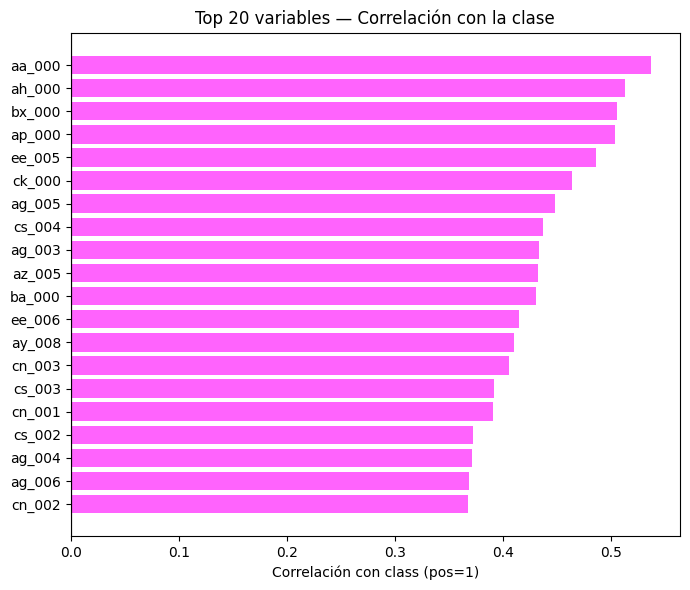

In [77]:
# correlación de cada variable con la clase (point-biserial, ya que la clase es binaria 0/1)
corr_class = X_train_full.corrwith(y_train_full).sort_values(key=lambda s: s.abs(), ascending=False)

top20_class = corr_class.head(20)
print(top20_class)

fig, ax = plt.subplots(figsize=(7, 6))
orden = top20_class.sort_values().index   # para que el gráfico quede ordenado de menor a mayor
valores = top20_class.loc[orden]
colores = ['#ff48fd' if v > 0 else '#007aff' for v in valores]
ax.barh(orden, valores, color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Correlación con class (pos=1)")
ax.set_title("Top 20 variables — Correlación con la clase")
plt.tight_layout()
plt.show()


### Vamos a aplicar un BASELINE con la variables de mayor correlacion con el target y tambien con las 5 variables que mejor correlacionan hacer una votacion 

In [91]:
# Baseline heurístico: umbral sobre aa_000 (variable con mayor correlación con la clase), sin entrenar ningún modelo
var_baseline = 'aa_000'

valor_neg = X_train.loc[y_train == 0, var_baseline]
valor_pos = X_train.loc[y_train == 1, var_baseline]
umbral_baseline = (valor_neg.median() + valor_pos.median()) / 2

y_pred_baseline = (X_test[var_baseline] > umbral_baseline).astype(int)


#### Definimos una funciona de costo

In [92]:
def costo(y_true, y_pred):
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return fn * 500 + fp * 10


In [93]:
top5 = corr_class.abs().sort_values(ascending=False).head(5).index.tolist()

# umbral por variable: punto medio entre la mediana de la clase neg y la de la clase pos
umbrales_top5 = {}
for var in top5:
    valor_neg = X_train.loc[y_train == 0, var]
    valor_pos = X_train.loc[y_train == 1, var]
    umbrales_top5[var] = (valor_neg.median() + valor_pos.median()) / 2

print(umbrales_top5)

# para cada variable, 1 si supera su umbral, 0 si no
votos = pd.DataFrame({var: (X_test[var] > umbrales_top5[var]).astype(int) for var in top5})
conteo_votos = votos.sum(axis=1)

# predice falla si la mayoría (al menos 3 de 5) de las variables "alarman"
y_pred_baseline5 = (conteo_votos >= 3).astype(int)


{'aa_000': np.float64(300337.0), 'ah_000': np.float64(8957333.0), 'bx_000': np.float64(20649905.5), 'ap_000': np.float64(5375875.0), 'ee_005': np.float64(1432851.0)}


In [94]:
modelos = ["Baseline (umbral aa_000)", "Baseline (voto mayoría top5)"]
preds = [y_pred_baseline, y_pred_baseline5]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds],
    "Costo": [costo(y_test, yp) for yp in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (umbral aa_000),0.5377,0.8635,0.4184,0.752,50420
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.808,39840


### Vamos a aplicar Regresion Logistica

##### Busqueda de hiperparametros

In [49]:
clf_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

hyperparams = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced", {0: 1, 1: 50}, {0: 1, 1: 30}]
}

grid = GridSearchCV(clf_logreg,
                    hyperparams,
                    refit=True,
                    cv=5,
                    scoring='f1',
                    n_jobs=-1)
grid.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=5000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced', ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [64]:
grid.best_params_

{'model__C': 0.1,
 'model__class_weight': None,
 'model__penalty': 'l2',
 'model__solver': 'liblinear'}

elegidos los parametros corremos el modelo

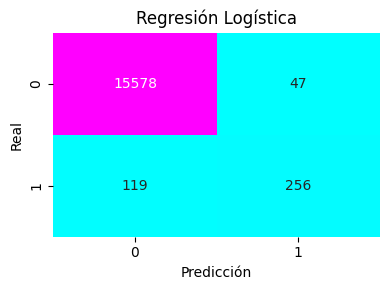

In [65]:
best_logreg = grid.best_estimator_

y_pred = best_logreg.predict(X_test)
cm_logreg = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Regresión Logística")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [66]:
TN, FP, FN, TP = cm_logreg.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Regresión Logística")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Costo total = {FP * 10 + FN * 500:.0f} (FP: {FP}, FN: {FN})")

Regresión Logística
Sensibilidad (Recall): 0.6827
Especificidad:         0.9970
Exactitud balanceada:  0.8398
Precisión:             0.8449
Recall:                0.6827
F1-score:              0.7552
Costo total = 59970 (FP: 47, FN: 119)


In [ ]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.01, 0.10, 0.01):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo_i = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

   umbral  FN   FP  costo
0    0.01   9  729  11790
1    0.02  12  358   9580
2    0.03  20  274  12740
3    0.04  24  228  14280
4    0.05  27  193  15430
5    0.06  27  177  15270
6    0.07  27  160  15100
7    0.08  31  148  16980
8    0.09  32  137  17370

Mejor umbral:
umbral       0.02
FN          12.00
FP         358.00
costo     9580.00
Name: 1, dtype: float64


In [ ]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.010, 0.030, 0.001):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo_i = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

    umbral  FN   FP  costo
0    0.010   9  729  11790
1    0.011   9  644  10940
2    0.012  10  583  10830
3    0.013  10  533  10330
4    0.014  11  493  10430
5    0.015  11  468  10180
6    0.016  11  442   9920
7    0.017  12  423  10230
8    0.018  12  397   9970
9    0.019  12  379   9790
10   0.020  12  358   9580
11   0.021  12  349   9490
12   0.022  12  337   9370
13   0.023  13  328   9780
14   0.024  16  321  11210
15   0.025  16  310  11100
16   0.026  17  306  11560
17   0.027  19  297  12470
18   0.028  19  286  12360
19   0.029  19  281  12310

Mejor umbral:
umbral       0.022
FN          12.000
FP         337.000
costo     9370.000
Name: 12, dtype: float64


In [63]:
probs_test = grid.best_estimator_.predict_proba(X_test)[:, 1]
umbral_final = 0.022
y_pred_test = (probs_test >= umbral_final).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
costo_final = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final en test: {costo_final}")
print(classification_report(y_test, y_pred_test, digits=3))

TN=15226, FP=399, FN=27, TP=348
Costo final en test: 17490
              precision    recall  f1-score   support

           0      0.998     0.974     0.986     15625
           1      0.466     0.928     0.620       375

    accuracy                          0.973     16000
   macro avg      0.732     0.951     0.803     16000
weighted avg      0.986     0.973     0.978     16000



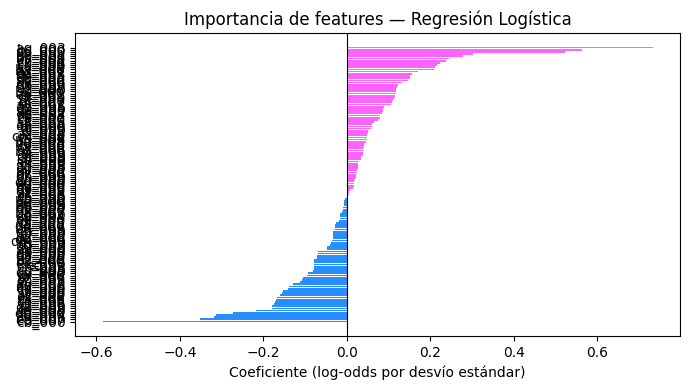

In [68]:
coefs = best_logreg.named_steps['model'].coef_.ravel()
orden = np.argsort(coefs)

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#ff48fd' if c > 0 else '#007aff' for c in coefs[orden]]
feature_names = X_train.columns
ax.barh(np.array(feature_names)[orden], coefs[orden], color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Coeficiente (log-odds por desvío estándar)")
ax.set_title("Importancia de features — Regresión Logística")
plt.tight_layout()
plt.show()

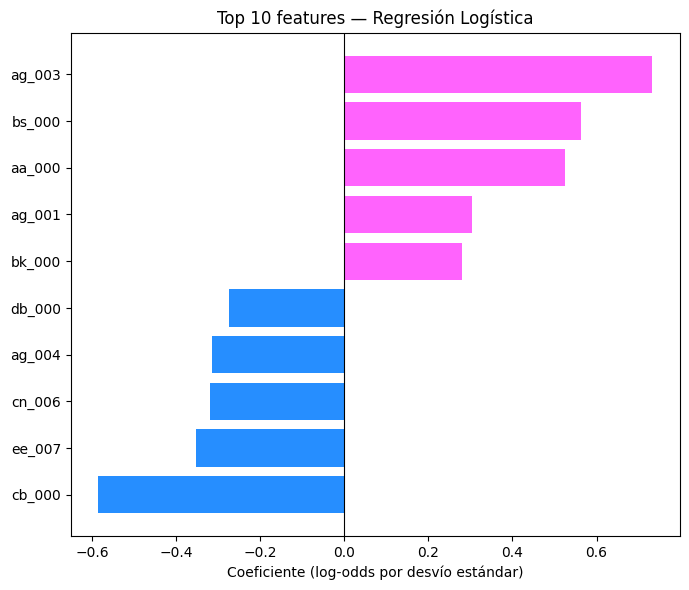

In [76]:
coefs = best_logreg.named_steps['model'].coef_.ravel()
feature_names = X_train.columns

n_top = 10
orden_abs = np.argsort(np.abs(coefs))[-n_top:]   # las n_top con mayor |coeficiente|
orden = orden_abs[np.argsort(coefs[orden_abs])]   # las reordena de menor a mayor para el gráfico

fig, ax = plt.subplots(figsize=(7, 6))
colores = ['#ff48fd' if c > 0 else '#007aff' for c in coefs[orden]]
ax.barh(np.array(feature_names)[orden], coefs[orden], color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Coeficiente (log-odds por desvío estándar)")
ax.set_title(f"Top {n_top} features — Regresión Logística")
plt.tight_layout()
plt.show()


In [95]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.022)"]
preds_final = [y_pred_baseline5, y_pred_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.808,39840
Regresión Logística (umbral 0.022),0.6203,0.9512,0.4659,0.928,17490


### Vamos a aplicar SVM

Antes de entrenar el data set completo y esto lleva mucho tiempo, vamos a realizar un muestreo del data set el con el cual vamos a seleccionar los hiperparametros a utilizar.

In [108]:
X_train_muestra, _, y_train_muestra, _ = train_test_split(
    X_train, y_train,
    train_size=8000,
    stratify=y_train,
    random_state=42
)


In [109]:
X_train_muestra.shape, y_train_muestra.shape

((8000, 126), (8000,))

Vamos a utilizar GridserachCV para la seleccion de hiperparametros

In [110]:
from sklearn.svm import SVC

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

hiper_svm = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"],   # se ignora automáticamente si kernel='linear'
    "model__class_weight": [None, "balanced"],
}

grid_svm = GridSearchCV(clf_svm,
                         hiper_svm,
                         refit=True,
                         cv=5,
                         scoring='f1',
                         n_jobs=-1)
grid_svm.fit(X_train_muestra, y_train_muestra)


,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [111]:
print(grid_svm.best_params_)

{'model__C': 0.1, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'linear'}


Obtenemos los mejores hiperparametrso calculados por el GridsearchCV, lo raro es que el 'model_class_weight':None, o sea no usa el balanceo de las variables a pesar de que esten muy desbalanceadas. Esto lo hace porque usa el scoring='f1', que fuerza a que de bien el valor de 'f1' en lugar del 'recall' que es el que nosotros quisieramos optimizar. Pero si pondriamos scoring='reacall' tambien nos daria muy mal porque el sistema forzaria  a que el recall de perfecto pero el resto de las clasificaciones darian muy mal. Ademas un punto a tener en cuenta que en todos los casoso el .predict() usa un umbral de 0,5 que para el caso nuestro que es un sistema muy desbalanceado nos juega en contra.
Lo que podemos hacer para mejorar la seleccion de hiperparametros es utilizar una funcion de costo, que es lo que que define el objetivo de nuestro problemas, minimizar el costo total de mantenimiento, lo cual penaliza muchisimos si tiene muchhos FN y que el costo de los mismos es 50 veces mas caro que un FP

#### Funcion de costo

In [112]:
def costo(y_true, y_pred):
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return fn * 500 + fp * 10


Se agrega la funcion make_scorer que esto le permite a la busqueda de hiperparametros que mejan el costo del problema, que es minimizarlo, en lugar de utilizar alguna metrica especifica.

In [114]:
from sklearn.metrics import make_scorer

costo_scorer = make_scorer(costo, greater_is_better=False)

grid_svm = GridSearchCV(clf_svm,
                         hiper_svm,
                         refit=True,
                         cv=5,
                         scoring=costo_scorer,
                         n_jobs=-1)
grid_svm.fit(X_train_muestra, y_train_muestra)


,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf']}"
,scoring,make_scorer(c...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [115]:
grid_svm.best_params_

{'model__C': 0.1,
 'model__class_weight': 'balanced',
 'model__gamma': 'scale',
 'model__kernel': 'rbf'}

Ahora con esta seleccion de hiperparametros vamos a correr el train del modelo completo, pero agregando el probability=True, los que no va a dar el resultado probable de cada seleccion. Como en el el entrenamiento utiliza .predict() el umbral de 0,5 nosotros con el set de validacion vamos a probar cambiar estos valores para ver si mejora la performance  del modelo

Vamos a agregar codigo tambien para medir el tiempo utilizado en el entrenamiento y el costo de computo utilizado

In [116]:
clf_svm_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(C=0.1, kernel='rbf', gamma='scale', class_weight='balanced', probability=True, random_state=42))
])



In [117]:
import time
import psutil
import os

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

clf_svm_final.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de entrenamiento: {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")


Tiempo de entrenamiento: 485.83 segundos
Memoria usada: -4.96 MB (antes: 147.98 MB, después: 143.02 MB)


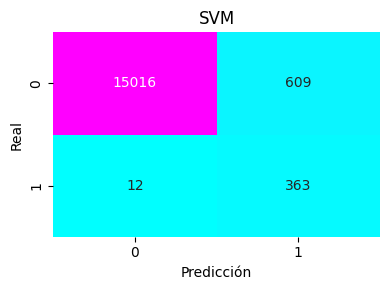

SVM (umbral 0.5, sin ajustar)
Sensibilidad (Recall): 0.9680
Especificidad:         0.9610
Exactitud balanceada:  0.9645
Precisión:             0.3735
Recall:                0.9680
F1-score:              0.5390
Costo total = 12090 (FP: 609, FN: 12)


In [119]:
y_pred_svm = clf_svm_final.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("SVM")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_svm.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("SVM (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_svm)} (FP: {FP}, FN: {FN})")


Ahora vamos a probar ajustar el umbal de 0,5 a ver si mejora incluso mas el ajuste para optimizar el costo. Esta prueba la vamos a hacer con paquete de validacion.

In [120]:
probs_svm = clf_svm_final.predict_proba(X_val)[:, 1]

resultados_svm = []
for umbral in np.arange(0.05, 1.00, 0.05):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_svm = pd.DataFrame(resultados_svm)
print(tabla_svm)

mejor_fila_svm = tabla_svm.loc[tabla_svm['costo'].idxmin()]
print("\nMejor umbral SVM (barrido grueso):")
print(mejor_fila_svm)


    umbral   FN   FP  costo
0     0.05    8  451   8510
1     0.10    9  382   8320
2     0.15   11  319   8690
3     0.20   11  283   8330
4     0.25   13  245   8950
5     0.30   17  192  10420
6     0.35   87   73  44230
7     0.40  124   48  62480
8     0.45  142   38  71380
9     0.50  175   33  87830
10    0.55  180   29  90290
11    0.60  183   21  91710
12    0.65  188   20  94200
13    0.70  189   18  94680
14    0.75  192   12  96120
15    0.80  193    9  96590
16    0.85  194    5  97050
17    0.90  196    3  98030
18    0.95  198    1  99010

Mejor umbral SVM (barrido grueso):
umbral       0.1
FN           9.0
FP         382.0
costo     8320.0
Name: 1, dtype: float64


Queremos hacer zoom en el umbral 0,35 que cae de golpe los FN a pesar que no es el punto de menor costo hay alguno evento que ocurre que fallen muchos camiones en ese punto.

In [121]:
resultados_svm_zoom = []
for umbral in np.arange(0.25, 0.36, 0.01):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm_zoom.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

pd.DataFrame(resultados_svm_zoom)


,umbral,FN,FP,costo
0,0.25,13,245,8950
1,0.26,13,238,8880
2,0.27,15,229,9790
3,0.28,16,219,10190
4,0.29,16,204,10040
5,0.30,17,192,10420
6,0.31,18,179,10790
7,0.32,19,168,11180
8,0.33,21,161,12110
9,0.34,27,140,14900


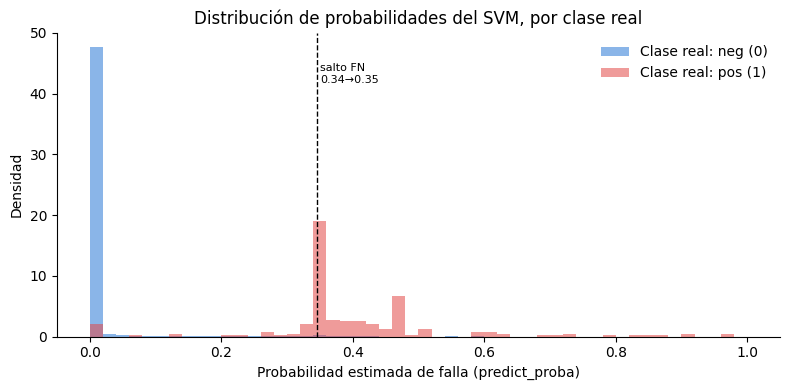

In [123]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = np.arange(0, 1.02, 0.02)

ax.hist(probs_svm[y_val == 0], bins=bins, density=True, alpha=0.55,
        color='#2a78d6', label='Clase real: neg (0)')
ax.hist(probs_svm[y_val == 1], bins=bins, density=True, alpha=0.55,
        color='#e34948', label='Clase real: pos (1)')

ax.axvline(0.345, color='k', linestyle='--', linewidth=1)
ax.text(0.35, ax.get_ylim()[1]*0.9, 'salto FN\n0.34→0.35', fontsize=8, va='top')

ax.set_xlabel('Probabilidad estimada de falla (predict_proba)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades del SVM, por clase real')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

En el grafico se muesta lo que creiamos ese umbral de probabilidades ocurre algun evento/os en particular que hace que muchos camiones fallen.

Ahora vamos a afinar los umbrales para ver si podemos mejorar el desempeño del costo

In [125]:
resultados_svm_fino = []
for umbral in np.arange(0.05, 0.21, 0.01):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm_fino.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_svm_fino = pd.DataFrame(resultados_svm_fino)
print(tabla_svm_fino)

mejor_fila_svm_fino = tabla_svm_fino.loc[tabla_svm_fino['costo'].idxmin()]
print("\nMejor umbral SVM (barrido fino):")
print(mejor_fila_svm_fino)


    umbral  FN   FP  costo
0     0.05   8  451   8510
1     0.06   8  429   8290
2     0.07   9  411   8610
3     0.08   9  397   8470
4     0.09   9  391   8410
5     0.10   9  382   8320
6     0.11   9  368   8180
7     0.12   9  356   8060
8     0.13  10  345   8450
9     0.14  11  330   8800
10    0.15  11  319   8690
11    0.16  11  311   8610
12    0.17  11  307   8570
13    0.18  11  298   8480
14    0.19  11  292   8420
15    0.20  11  283   8330

Mejor umbral SVM (barrido fino):
umbral       0.12
FN           9.00
FP         356.00
costo     8060.00
Name: 7, dtype: float64


Con el mejor umbral seleccionado ahora lo corremos contra el paquete de test

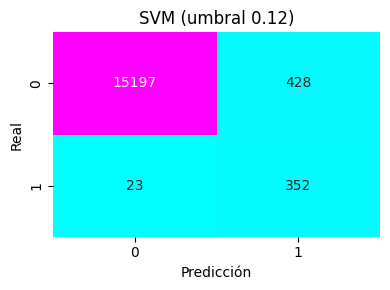

TN=15197, FP=428, FN=23, TP=352
Costo final SVM en test: 15780
              precision    recall  f1-score   support

           0      0.998     0.973     0.985     15625
           1      0.451     0.939     0.610       375

    accuracy                          0.972     16000
   macro avg      0.725     0.956     0.797     16000
weighted avg      0.986     0.972     0.977     16000



In [127]:
probs_svm_test = clf_svm_final.predict_proba(X_test)[:, 1]
umbral_final_svm = 0.12
y_pred_svm_test = (probs_svm_test >= umbral_final_svm).astype(int)

cm_svm_test = confusion_matrix(y_test, y_pred_svm_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_svm_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("SVM (umbral 0.12)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_svm_test.ravel()
costo_final_svm = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final SVM en test: {costo_final_svm}")
print(classification_report(y_test, y_pred_svm_test, digits=3))



Ahora vamos a hacer una comparación de los modelos que se fueron utilizando

In [128]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.022)", "SVM (umbral 0.12)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.8080,39840
Regresión Logística (umbral 0.022),0.6203,0.9512,0.4659,0.9280,17490
SVM (umbral 0.12),0.6095,0.9556,0.4513,0.9387,15780
